In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF
import torchvision.transforms as transforms
import cv2

import math

import os

In [2]:
def get_blockwise_orientation(
    source_image: torch.Tensor,
    block_size: int = 8,
):
    dev = source_image.device
    dtype = source_image.dtype

    sobel_x = torch.tensor(
        [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=dtype, device=dev
    ).view(1, 1, 3, 3)
    sobel_y = torch.tensor(
        [[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=dtype, device=dev
    ).view(1, 1, 3, 3)
    blur = transforms.GaussianBlur(kernel_size=5)

    img = source_image.clone()
    img = blur(img.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)

    Gx = F.conv2d(img.unsqueeze(0).unsqueeze(0), sobel_x, padding=1)
    Gy = F.conv2d(img.unsqueeze(0).unsqueeze(0), sobel_y, padding=1)

    Gx2 = Gx * Gx
    Gy2 = Gy * Gy
    Gxy = Gx * Gy

    kernel = torch.ones(
        (1, 1, block_size, block_size), dtype=Gx2.dtype, device=Gx2.device
    )

    sum_Gx2 = F.avg_pool2d(Gx2, kernel_size=block_size, stride=block_size) * (
        block_size * block_size
    )
    sum_Gy2 = F.avg_pool2d(Gy2, kernel_size=block_size, stride=block_size) * (
        block_size * block_size
    )
    sum_Gxy = F.avg_pool2d(Gxy, kernel_size=block_size, stride=block_size) * (
        block_size * block_size
    )

    Vx = 2.0 * sum_Gxy.squeeze(0).squeeze(0)
    Vy = sum_Gx2.squeeze(0).squeeze(0) - sum_Gy2.squeeze(0).squeeze(0)

    theta = 0.5 * torch.atan2(Vx, Vy + 1e-8)

    Tx = torch.cos(2.0 * theta)
    Ty = torch.sin(2.0 * theta)

    Tprime_x = blur(Tx.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)
    Tprime_y = blur(Ty.unsqueeze(0).unsqueeze(0)).squeeze(0).squeeze(0)

    theta = 0.5 * torch.atan2(Tprime_y, Tprime_x)
    orientation_map = torch.remainder(theta, torch.pi)

    return orientation_map

In [3]:
from torchvision import transforms

spiral_image = cv2.imread("images/spiral_phase.jpg", cv2.IMREAD_GRAYSCALE)
spiral_image = spiral_image / 255.0
h, w = spiral_image.shape

# normalize
target_spiral_image = torch.from_numpy(spiral_image).float()
target_spiral_image = target_spiral_image / target_spiral_image.max()

non_spiral_image = cv2.imread("images/cont_phase.jpg", cv2.IMREAD_GRAYSCALE)
non_spiral_image = non_spiral_image / 255.0

target_non_spiral_image = torch.from_numpy(non_spiral_image).float()
target_non_spiral_image = target_non_spiral_image / target_non_spiral_image.max()



In [4]:
def apply_spatially_variant_gabor(image, orientation_field, kernel_size=16, freq=0.1, sigma=4.0):
    """
    image: (B, 1, H, W) - The input image (256x256)
    orientation_field: (B, 1, H_low, W_low) - The orientation matrix (32x32)
    kernel_size: Scalar - Size of the Gabor kernel (e.g., 16)
    freq: Scalar - The frequency of the Gabor filter
    """
    B, _, H, W = image.shape
    assert orientation_field.shape == image.shape

    padding = kernel_size // 2

    # unfolded shape: (B, C * K * K, L) where L = H * W
    image_unfolded = F.unfold(image, kernel_size=kernel_size, padding=padding)

    range_x = torch.linspace(
        -(kernel_size // 2), kernel_size // 2, kernel_size, device=image.device
    )
    range_y = torch.linspace(
        -(kernel_size // 2), kernel_size // 2, kernel_size, device=image.device
    )
    grid_y, grid_x = torch.meshgrid(range_y, range_x, indexing="ij")

    # Flatten grid to match unfolded dimension (K*K, 1)
    grid_x = grid_x.reshape(-1, 1)  # (K*K, 1)
    grid_y = grid_y.reshape(-1, 1)  # (K*K, 1)

    theta = orientation_field.reshape(B, 1, -1)  # (B, 1, L)

    x_rot = grid_x * torch.cos(theta) + grid_y * torch.sin(theta)
    y_rot = -grid_x * torch.sin(theta) + grid_y * torch.cos(theta)

    # Gaussian envelope (circular symmetric here for simplicity)
    envelope = torch.exp(-0.5 * (x_rot**2 + y_rot**2) / sigma**2)
    carrier = torch.cos(2 * math.pi * freq * x_rot)

    kernels = envelope * carrier

    out_unfolded = (image_unfolded * kernels).sum(dim=1, keepdim=True)  # (B, 1, L)

    # Reshape back to image format (B, 1, H, W)
    out_image = out_unfolded.view(B, 1, H, W)

    return out_image

In [5]:
import torch
import torch.nn.functional as F
import math


def apply_blockwise_gabor(
    image, orientation_matrix, kernel_size=16, block_size=8, freq=0.1
):
    """
    image: (B, 1, 256, 256)
    orientation_matrix: (B, 1, 32, 32)
    """
    B, C, H, W = image.shape
    device = image.device

    # 1. Determine the necessary input patch size
    # To get a valid 'block_size' output (8x8) from a 'kernel_size' filter (16x16),
    # we need an input of size: 8 + 16 - 1 = 23
    input_patch_size = block_size + kernel_size - 1

    # Calculate padding needed for the original image to allow this unfolding
    # We want to unfold with stride=8 to get exactly 32x32 patches
    padding_total = input_patch_size - block_size
    pad_h = padding_total // 2
    pad_w = padding_total - pad_h

    image_padded = F.pad(image, (pad_w, pad_w, pad_h, pad_h))

    patches = F.unfold(image_padded, kernel_size=input_patch_size, stride=block_size)

    # Reshape patches to look like a "batch" of images for Grouped Conv
    # Shape: (1, B * TotalBlocks, input_patch_size, input_patch_size)
    # We put everything into the Channel dimension because 'groups' splits the channel dimension.
    num_blocks = patches.shape[-1]  # Should be 32*32 = 1024
    patches_reshaped = patches.view(
        1, B * num_blocks, input_patch_size, input_patch_size
    )

    # 3. Generate Kernels for each Block
    # orientation_matrix is (B, 1, 32, 32) -> Flatten to (B * 1024)
    thetas = orientation_matrix.view(-1)

    # Generate grid for ONE kernel
    range_k = torch.linspace(
        -(kernel_size // 2), kernel_size // 2, kernel_size, device=device
    )
    grid_y, grid_x = torch.meshgrid(range_k, range_k, indexing="ij")
    grid_x = grid_x.flatten()  # (K*K)
    grid_y = grid_y.flatten()  # (K*K)

    c = torch.cos(thetas).unsqueeze(1)
    s = torch.sin(thetas).unsqueeze(1)

    x_rot = grid_x * c + grid_y * s
    y_rot = -grid_x * s + grid_y * c
    
    # Calculate Gabor carrier
    carrier = torch.cos(2.0 * torch.pi * freq * x_rot)

    sigma = 4.0
    envelope = torch.exp(-0.5 * (x_rot**2 + y_rot**2) / sigma**2).unsqueeze(
        0
    ) 

    # Final Kernels: (TotalBlocks, 1, K, K)
    filters = (envelope * carrier).view(-1, 1, kernel_size, kernel_size)

    output_blocks = F.conv2d(patches_reshaped, filters, groups=B * num_blocks)

    out = output_blocks.view(B, 32, 32, block_size, block_size)
    out = out.permute(0, 1, 3, 2, 4).contiguous()
    out = out.view(B, 1, H, W)

    return out

Plotting 6 kernels with Freq=0.12, Sigma=10.0


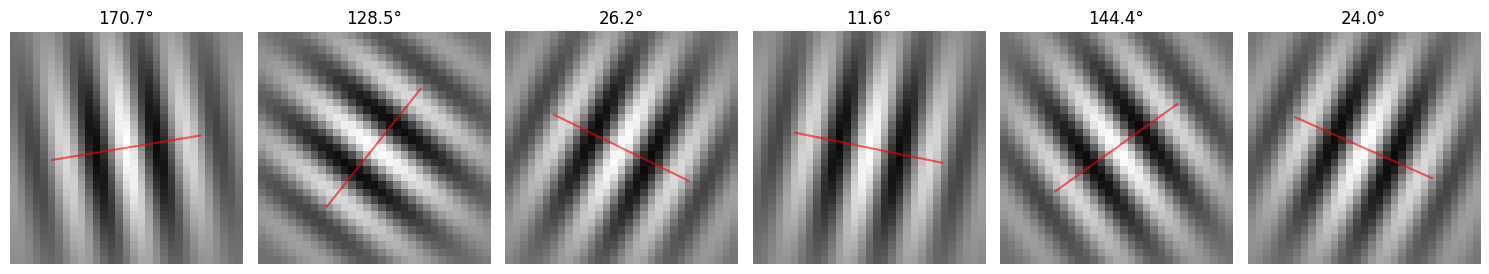

In [6]:
import torch
import matplotlib.pyplot as plt
import math
import random

def plot_random_gabor_kernels(num_kernels=6, kernel_size=16, freq=0.15, sigma=4.0):
    """
    Generates random orientations and visualizes the corresponding Gabor kernels.
    """
    # 1. Generate Random Orientations (between 0 and 180 degrees)
    # We use 0 to pi because fingerprint orientation is usually undirected (0-180)
    orientations = torch.rand(num_kernels) * math.pi
    
    # 2. Create the Grid (Standard meshgrid logic)
    # Range centered around 0
    range_k = torch.linspace(-(kernel_size // 2), kernel_size // 2, kernel_size)
    grid_y, grid_x = torch.meshgrid(range_k, range_k, indexing='ij')
    
    # Flatten for vectorized calculation
    grid_x = grid_x.flatten() # Shape: (K*K)
    grid_y = grid_y.flatten() # Shape: (K*K)
    
    # 3. Vectorized Rotation & Generation
    # We broadcast (num_kernels) against (K*K) grid points
    c = torch.cos(orientations).unsqueeze(1) # Shape: (N, 1)
    s = torch.sin(orientations).unsqueeze(1) # Shape: (N, 1)
    
    # Rotate grid: x_rot = x*cos + y*sin
    x_rot = grid_x * c + grid_y * s # Shape: (N, K*K)
    
    # Calculate components
    # Envelope (Gaussian): shape (1, K*K) -> broadcast to (N, K*K)
    # Note: we use unsqueeze(0) because the envelope is the same for all rotations
    envelope = torch.exp(-0.5 * (grid_x**2 + grid_y**2) / sigma**2).unsqueeze(0)
    
    # Carrier (Cosine): shape (N, K*K)
    carrier = torch.cos(2 * math.pi * freq * x_rot)
    
    # Combine and reshape to (N, H, W)
    kernels = (envelope * carrier).view(num_kernels, kernel_size, kernel_size)

    # 4. Plotting
    fig, axes = plt.subplots(1, num_kernels, figsize=(15, 3))
    
    # Handle edge case if num_kernels=1
    if num_kernels == 1: axes = [axes]

    print(f"Plotting {num_kernels} kernels with Freq={freq}, Sigma={sigma}")
    
    for i in range(num_kernels):
        kernel_data = kernels[i].numpy()
        angle_deg = math.degrees(orientations[i].item())
        
        ax = axes[i]
        # Use 'gray' colormap; origin='upper' matches image coordinates
        im = ax.imshow(kernel_data, cmap='gray', vmin=-1, vmax=1)
        ax.set_title(f"{angle_deg:.1f}°")
        ax.axis('off')
        
        # Optional: Add a small red line indicating the intended orientation
        center = kernel_size // 2
        length = kernel_size // 3
        # Note: sin/cos are flipped for plotting (y is down) vs standard math
        dx = length * math.cos(orientations[i].item())
        dy = length * math.sin(orientations[i].item()) 
        ax.plot([center - dx, center + dx], [center - dy, center + dy], 'r-', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Run the visualization ---
plot_random_gabor_kernels(freq=0.12, sigma=10.0, kernel_size=31)

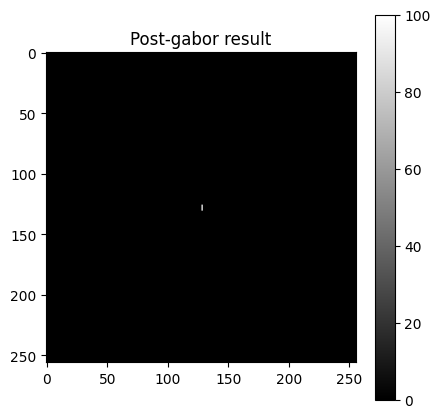

In [7]:
from gabor_torch import gabor_kernel_torch
orientation_no_spiral = get_blockwise_orientation(target_non_spiral_image, block_size=8)
image_with_seed = torch.zeros_like(target_non_spiral_image)

# mark the center with a small cross
center_y = h // 2
center_x = w // 2
image_with_seed[center_y - 2 : center_y + 3, center_x] = 100.0

# plot
plt.figure(figsize=(5, 5))
plt.title("Post-gabor result")
plt.imshow(image_with_seed.cpu(), cmap="gray")
plt.colorbar()
plt.show()

In [8]:
upsampled_orientation = F.interpolate(
    orientation_no_spiral.unsqueeze(0).unsqueeze(0),
    size=(h, w),
    mode="bilinear",
    align_corners=False,
)

# plt.figure(figsize=(5, 5))
# plt.title("Orientation Field")
# plt.imshow(upsampled_orientation.squeeze(0).squeeze(0)[124:129, :].cpu(), cmap="gray")
# plt.colorbar()


In [9]:
for _ in range(100):
    filtered = (
        apply_spatially_variant_gabor(
            image_with_seed.unsqueeze(0).unsqueeze(0),
            upsampled_orientation,
            kernel_size=31,
            freq=0.07,
            sigma=10.0,
        )
        .squeeze(0)
        .squeeze(0)
    )

    image_with_seed = filtered / filtered.max() * 255.0

KeyboardInterrupt: 

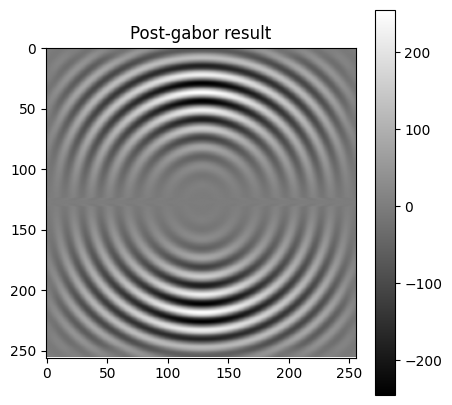

In [ ]:
# plot
plt.figure(figsize=(5, 5))
plt.title("Post-gabor result")
plt.imshow(image_with_seed.cpu(), cmap="gray")
plt.colorbar()
plt.show()

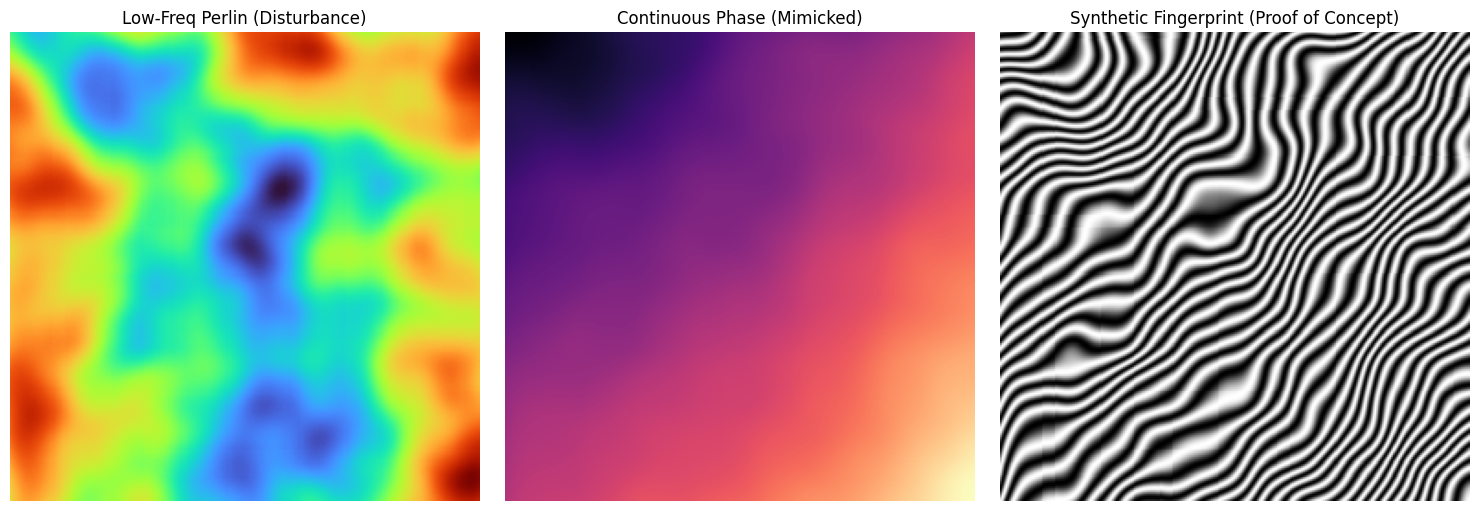

In [15]:
import torch
from pyperlin import FractalPerlin2D
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup
# -----------------------------
shape = (1, 256, 256)
device = "cpu"  # or 'cuda'

# TWEAK 1: Restrict Resolutions
# Fingerprint flow is low-frequency. We stop at 2^4 or 2^5.
# High freq (2^6, 2^7) creates "sand", not "flow".
resolutions = [(2**i, 2**i) for i in range(1, 5)]

# TWEAK 2: Adjust Factors
factors = [0.5**i for i in range(3)]

fp = FractalPerlin2D(shape, resolutions, factors, generator=torch.Generator(device))

# 2. Generate the "Perturbation" Field
# -----------------------------
# This is the "noise" that will warp our straight lines.
# We boost the magnitude (scale) significantly.
noise_field = fp() * 30.0

# -----------------------------
# Fingerprints are essentially stripes. A linear ramp creates stripes.
# The 'freq' controls the ridge density.
freq = 0.5
x = torch.arange(shape[2], device=device).float()
y = torch.arange(shape[1], device=device).float()
grid_y, grid_x = torch.meshgrid(y, x, indexing="ij")

base_phase = (grid_x + grid_y) * freq

continuous_phase = base_phase + noise_field.squeeze()

# 5. Visualize
# -----------------------------
# Convert phase to a visual "Fingerprint" using Cosine
# This effectively "wraps" the phase.
synthetic_fingerprint = torch.cos(continuous_phase)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: The Noise (The Disturbance)
axes[0].imshow(noise_field[0].cpu().numpy(), cmap="turbo")
axes[0].set_title("Low-Freq Perlin (Disturbance)")
axes[0].axis("off")

# Plot 2: The Continuous Phase (Unwrapped)
# This mimics the "Ground Truth" phase for your ML model
axes[1].imshow(continuous_phase.cpu().numpy(), cmap="magma")
axes[1].set_title("Continuous Phase (Mimicked)")
axes[1].axis("off")

# Plot 3: The Resulting Ridge Pattern
axes[2].imshow(synthetic_fingerprint.cpu().numpy(), cmap="gray")
axes[2].set_title("Synthetic Fingerprint (Proof of Concept)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

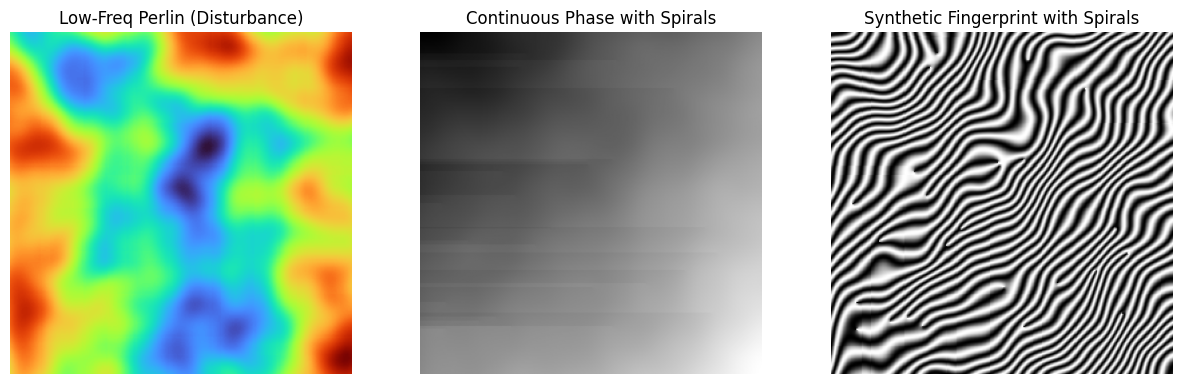

In [16]:
def add_spiral_phase(psi, points, polarities):
    # points: list of (y,x); polarities: +1 for termination, -1 for bifurcation (convention)
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    out = psi.copy()
    zero = np.zeros_like(psi)
    for (yy, xx), p in zip(points, polarities):
        zero += p * np.arctan2(Y - yy, X - xx)

    out += zero
    return out


spiral_phase_coords = []
spiral_phase_polarities = []

for _ in range(25):
    y = random.randint(12, 230)
    x = random.randint(12, 230)
    spiral_phase_coords.append((y, x))

    polarity = random.choice([1, -1])
    spiral_phase_polarities.append(polarity)

continuous_phase_spiral = add_spiral_phase(
    continuous_phase.cpu().numpy(), spiral_phase_coords, spiral_phase_polarities
)

synthetic_fingerprint_spiral = torch.cos(torch.from_numpy(continuous_phase_spiral).to(device))
# 5. Visualize
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Plot 1: The Noise (The Disturbance)
axes[0].imshow(noise_field[0].cpu().numpy(), cmap="turbo")
axes[0].set_title("Low-Freq Perlin (Disturbance)")
axes[0].axis("off")
# Plot 2: The Continuous Phase with Spirals (Unwrapped)
axes[1].imshow(continuous_phase_spiral, cmap="gray")
axes[1].set_title("Continuous Phase with Spirals")
axes[1].axis("off")

# Plot 3: The Resulting Ridge Pattern with Spirals
axes[2].imshow(synthetic_fingerprint_spiral.cpu().numpy(), cmap="gray")
axes[2].set_title("Synthetic Fingerprint with Spirals")
axes[2].axis("off")